In [41]:
##### Check region share of country total 
# for capital, labor, and ag production (as sense check)

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

In [20]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# Import sub-national data

sub_capital = pd.read_csv(f"{cd}/Data/Clean/Intensities/subnational_capital_intensity.csv")
sub_labor = pd.read_csv(f"{cd}/Data/Clean/Intensities/subnational_labor_intensity.csv")

sub_geo_capital = gpd.read_file(f"{cd}/Data/Clean/Capital_stock/subnational_capital_stock_final_GEO.shp")
sub_geo_labor = gpd.read_file(f"{cd}/Data/Clean/Labor/subnational_labor_final_geo.shp")

# Import country data

country_intensities = pd.read_csv(f"{cd}/Data/Clean/Intensities/country_intensities.csv")
country_shp = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/gadm_410-levels.gpkg", layer='ADM_0')

country_codes = pd.read_csv(f"{cd}/Data/Correspondence_tables/country_names.csv", encoding="cp1252")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures"

In [21]:
##### Calculate sub-national shares

# join data 
sub_capital['ISO3'] = sub_capital['PROJ_ID'].str[:3]
sub_labor['ISO3'] = sub_labor['PROJ_ID'].str[:3]

sub_capital = sub_capital.merge(country_intensities, on='ISO3', how='left')
sub_labor = sub_labor.merge(country_intensities, on='ISO3', how='left')

# calculate shares
sub_capital['share_capital_stock'] = (sub_capital['ag_capital_stock_USD_nominal'] / (sub_capital['ag_capital_stock_mil_USD_nominal'] * 1e6)) * 100
sub_capital['share_production'] = (sub_capital['total_production_USD'] / (sub_capital['ag_production_thousand_USD_2020'] * 1e3)) * 100
sub_capital['capital_intensity_ratio'] = sub_capital['capital_intensity_USD_per_USD_x'] / sub_capital['capital_intensity_USD_per_USD_y'] 

sub_labor['share_jobs'] = (sub_labor['ag_jobs'] / (sub_labor['ag_labor_thousands_2020'] * 1e3)) * 100
sub_labor['share_production'] = (sub_labor['total_production_USD'] / (sub_labor['ag_production_thousand_USD_2020'] * 1e3)) * 100
sub_labor['labor_intensity_ratio'] = sub_labor['labor_intensity_jobs_per_million_USD_x'] / sub_labor['labor_intensity_jobs_per_million_USD_y'] 


In [22]:
### Data prep

# align crs

crs = "ESRI:54042"

sub_geo_capital = sub_geo_capital.to_crs(crs)
sub_geo_labor = sub_geo_labor.to_crs(crs)
country_shp = country_shp.to_crs(crs)

# prep country shp 
country_shp = country_shp.merge(country_codes, left_on='GID_0', right_on='SHP_code', how='inner')

# join data to shape
sub_geo_capital = sub_geo_capital.merge(sub_capital, on='PROJ_ID', how='inner')
sub_geo_labor = sub_geo_labor.merge(sub_labor, on='PROJ_ID', how='inner')

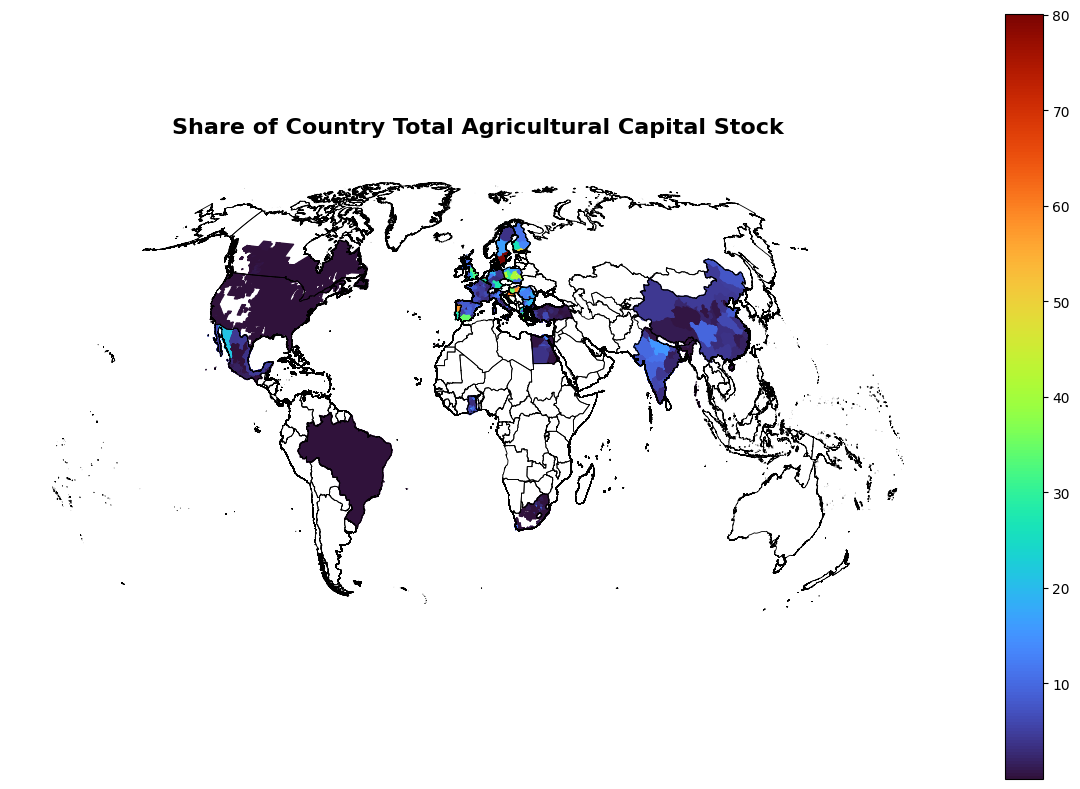

In [28]:
##### Plot sub-national share of capital 

### Plot
fig, ax = plt.subplots(figsize=(12,8))

# Plot buckets
sub_geo_capital.plot(
    column='share_capital_stock',
    cmap='turbo',
    edgecolor='face',
    ax=ax,
    legend=True,  
    zorder=2
)

# Add country boundaries
country_shp.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.6,
    zorder=10
)


# Aesthetics
ax.set_axis_off()  
ax.set_title("Share of Country Total Agricultural Capital Stock", fontsize=16, weight='bold', pad=20)
plt.tight_layout()

plt.show()

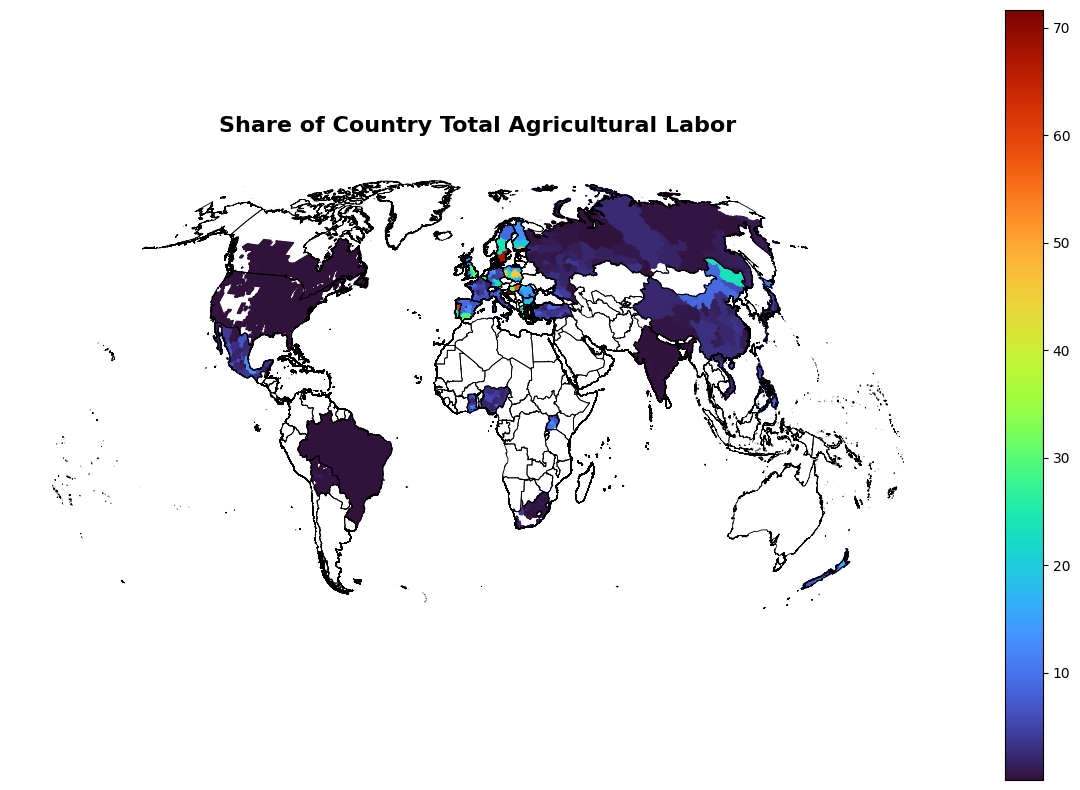

In [27]:
##### Plot sub-national share of labor 

### Plot
fig, ax = plt.subplots(figsize=(12,8))

# Plot buckets
sub_geo_labor.plot(
    column='share_jobs',
    cmap='turbo',
    edgecolor='face',
    ax=ax,
    legend=True,  
    zorder=2
)

# Add country boundaries
country_shp.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.6,
    zorder=10
)


# Aesthetics
ax.set_axis_off()  
ax.set_title("Share of Country Total Agricultural Labor", fontsize=16, weight='bold', pad=20)
plt.tight_layout()

plt.show()

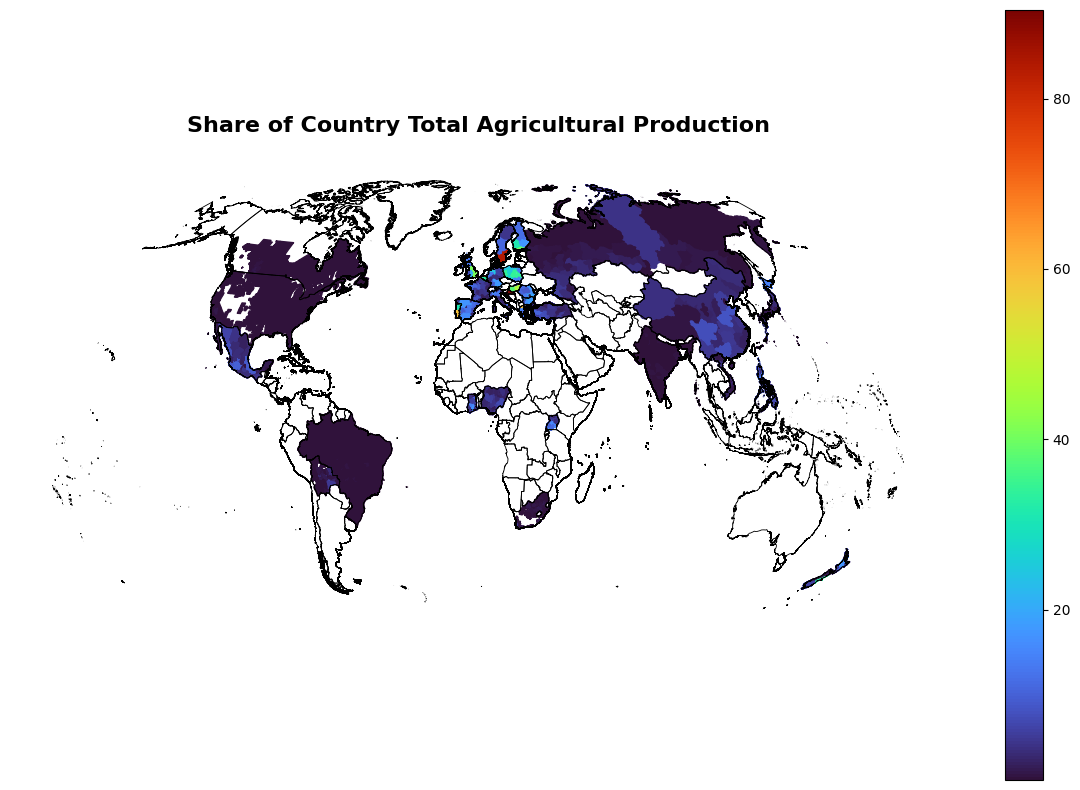

In [29]:
##### Plot sub-national share of production 

### Plot
fig, ax = plt.subplots(figsize=(12,8))

# Plot buckets
sub_geo_labor.plot(
    column='share_production',
    cmap='turbo',
    edgecolor='face',
    ax=ax,
    legend=True,  
    zorder=2
)

# Add country boundaries
country_shp.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.6,
    zorder=10
)


# Aesthetics
ax.set_axis_off()  
ax.set_title("Share of Country Total Agricultural Production", fontsize=16, weight='bold', pad=20)
plt.tight_layout()

plt.show()

In [33]:
sub_geo_capital['capital_intensity_ratio'].quantile([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

0.1    0.300855
0.2    0.537811
0.3    0.760569
0.4    1.000000
0.5    1.303045
0.6    1.686607
0.7    2.279780
0.8    3.610191
0.9    7.099000
Name: capital_intensity_ratio, dtype: float64

In [37]:
##### Create groupings for intensity ratios

# capital 
cap_bins = [0, 0.3, 0.6, 0.99, 1.02, 2, 4, float('inf')]
cap_labels = ['0-0.3', '0.3-0.6', '0.6-1', '1', '1-2', '2-4', '4+']

sub_geo_capital['bucket'] = pd.cut(
    sub_geo_capital['capital_intensity_ratio'],
    bins=cap_bins,
    labels=cap_labels
)

# labor 
lab_bins = [0, 0.3, 0.6, 0.99, 1.02, 2, 4, float('inf')]
lab_labels = ['0-0.3', '0.3-0.6', '0.6-1', '1', '1-2', '2-4', '4+']

sub_geo_labor['bucket'] = pd.cut(
    sub_geo_labor['labor_intensity_ratio'],
    bins=lab_bins,
    labels=lab_labels
)

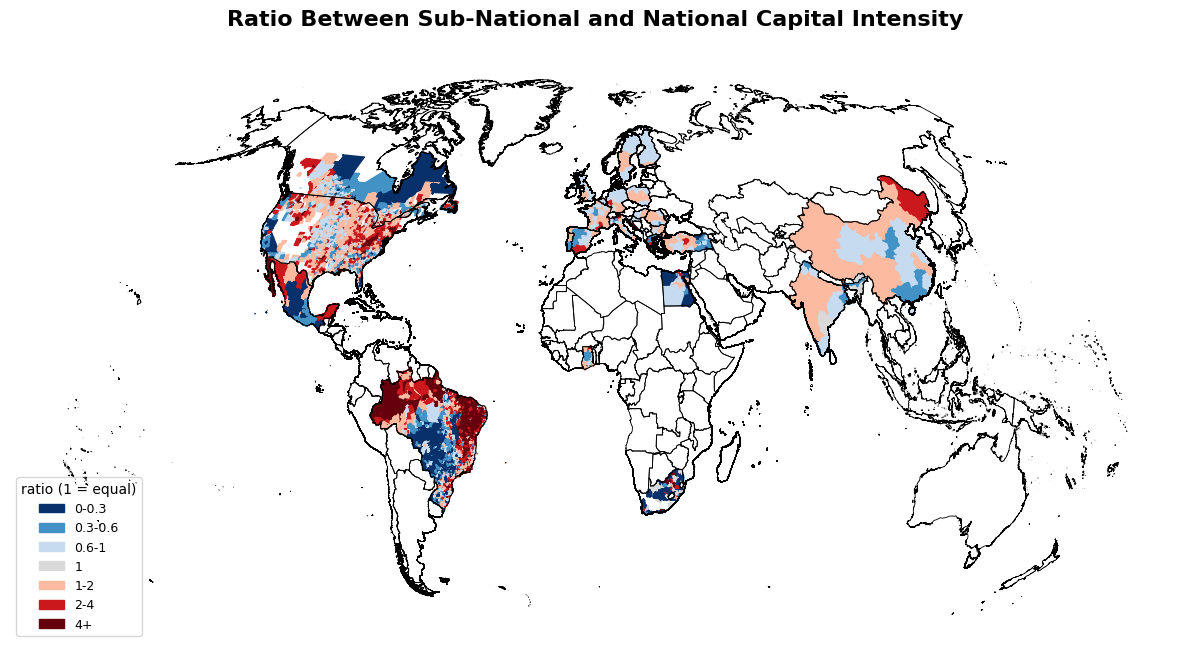

In [46]:
##### Plot ratio between sub-national and national capital intensities 

colors = [
    '#08306b',  # dark blue
    '#4292c6',  # medium blue
    '#c6dbef',  # light blue
    '#d9d9d9',  # light grey (≈1)
    '#fcbba1',  # light red
    '#cb181d',  # medium red
    '#67000d',  # dark red
]

cmap = mcolors.ListedColormap(colors)

### Plot
fig, ax = plt.subplots(figsize=(12, 8))

sub_geo_capital.plot(
    column='bucket',
    cmap=cmap,
    edgecolor='face',
    ax=ax,
    legend=False,
    zorder=2
)

country_shp.boundary.plot(ax=ax, color='black', linewidth=0.6, zorder=10)

patches = [mpatches.Patch(color=colors[i], label=cap_labels[i]) for i in range(len(cap_labels))]
ax.legend(
    handles=patches,
    title="ratio (1 = equal)",
    loc='lower left',
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

ax.set_axis_off()
ax.set_title("Ratio Between Sub-National and National Capital Intensity", fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/subnational_capital_intensity_ratio.png", dpi=300, bbox_inches='tight')

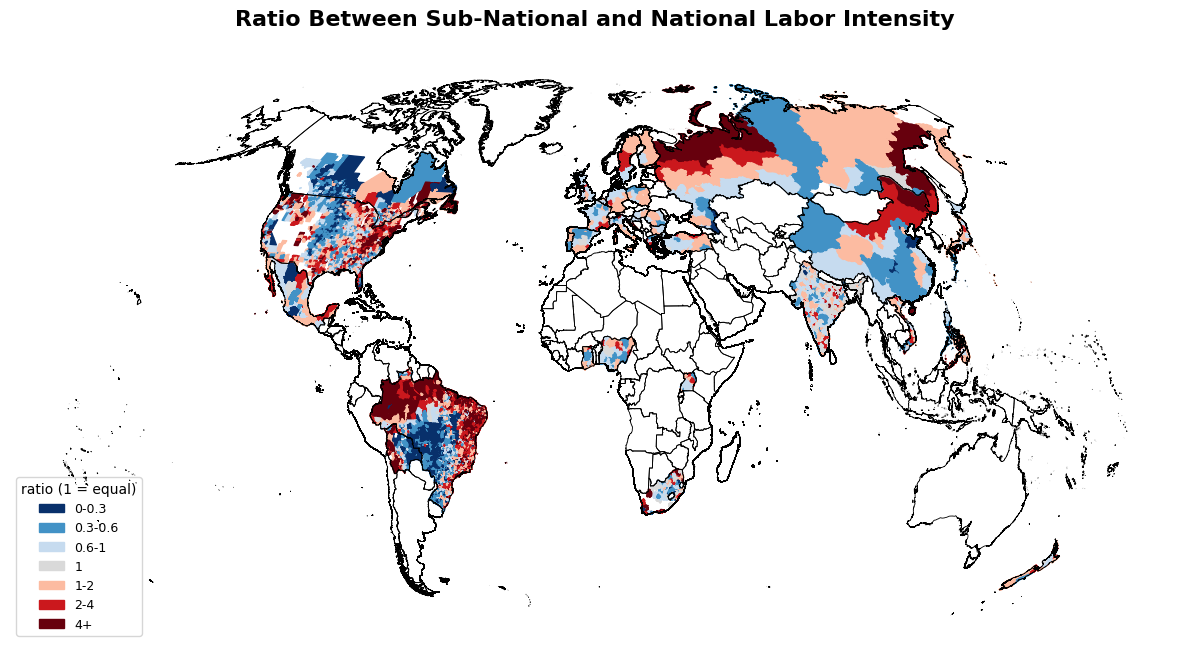

In [45]:
##### Plot ratio between sub-national and national labor intensities 

colors = [
    '#08306b',  # dark blue
    '#4292c6',  # medium blue
    '#c6dbef',  # light blue
    '#d9d9d9',  # light grey (≈1)
    '#fcbba1',  # light red
    '#cb181d',  # medium red
    '#67000d',  # dark red
]

cmap = mcolors.ListedColormap(colors)

### Plot
fig, ax = plt.subplots(figsize=(12, 8))

sub_geo_labor.plot(
    column='bucket',
    cmap=cmap,
    edgecolor='face',
    ax=ax,
    legend=False,
    zorder=2
)

country_shp.boundary.plot(ax=ax, color='black', linewidth=0.6, zorder=10)

patches = [mpatches.Patch(color=colors[i], label=lab_labels[i]) for i in range(len(lab_labels))]
ax.legend(
    handles=patches,
    title="ratio (1 = equal)",
    loc='lower left',
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

ax.set_axis_off()
ax.set_title("Ratio Between Sub-National and National Labor Intensity", fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/subnational_labor_intensity_ratio.png", dpi=300, bbox_inches='tight')